# Chapter 17: State and Consequence

The request left the controller. Its acknowledgement did not return. That observation supports two different stories: the tool may have done nothing, or it may have completed the effect and lost the reply. Sending the request again can resolve the first story and damage the second. A retry counter does not tell the controller which world it occupies.

This experiment gives you a local event ledger in which the actual effect and the received acknowledgement are separate fields. The ledger is constructed so the distinction can be inspected directly. In a real interface, the effect field would require an audit log, a durable receipt, or a verification query; it is not something the agent can infer from silence.

The default trace contains one effect without an acknowledgement and then a repeated request. First predict the cumulative effect count. Next ask what changes if the service stores an idempotency key and binds that key to the exact payload. Finally compare the cost of a verification query with the expected cost of a blind retry. These are three separate questions: what happened, what was confirmed, and what should happen next.

**Outcome:** Separate effects from acknowledgements and price a next recovery step.

- Inspect the declared input contract
- Predict the hand-checkable case
- Run the shared computation
- Change the critical assumption
- Apply the method to the transfer data

**Guided route:** Run the worked calculation, inspect its figure, change the stated assumption, and try the transfer case. Read the explanations beside each result before opening the answers.

**Deeper route:** First read the mathematics and canonical equation reference. Audit the input contract, predict the changed result, then inspect the shared chapter implementation and solve the questions independently. Both routes use the same calculations and preserve the equations.

## Technical Requirements

Python 3.11 or later, the complete laboratory folder, and the notebook dependencies listed in `requirements-notebooks.txt` (the launcher's **Install notebook tools** choice installs them; see START-HERE). Standard-library chapter commands also support Python 3.10. No API key, model account or network call is used by this experiment.

Prior knowledge:

- Python lists and dictionaries
- Event traces and conditional probability

## The question and its mathematics

Let E_t count durable effects after event t, and let C_t indicate whether at least one effect has been confirmed. A request whose effect flag is true increments E_t unless a valid idempotency contract recognizes the same key and payload. Its acknowledgement changes C_t; losing that acknowledgement does not undo the effect. A verification event can confirm an effect already present in the ledger.

An idempotency key is useful only if the receiving service records and checks it. Here the key maps to a payload identifier. Repeating the same pair suppresses an additional effect when idempotence is enabled. Reusing a stored key for a different payload raises an error because the requested contract is ambiguous. Counting repeated attempts without this mapping would not establish idempotence.

For one unresolved request, let p denote the conditional probability that it already took effect. Let c_r be the retry cost, d the harm of a duplicate, and c_v the cost of perfect verification. A nonidempotent retry has expected next-step cost c_r+pd. With the declared idempotency contract, duplicate harm vanishes and this comparison becomes c_r against c_v. This small calculation omits the benefit and cost of any later recovery steps.

The distinction between conditional belief and recorded truth matters. The trace says what happened in this constructed run; p represents what the controller believes before resolving an uncertain request. Neither quantity can replace the other in a deployed report.

## Apply this to an agent

A tool may perform an effect even when its acknowledgement is lost. Keep the effect ledger separate from what the agent knows, then compare verification with another request. An idempotency key works only when the tool stores and enforces its contract.

## A calculation you can run

Read the trace in order. A request includes a key, payload identifier, actual effect flag, and received acknowledgement flag. A verification includes whether the existing effect was observed. The computation maintains the effect count, key ledger, confirmation status, and unresolved-effect status, then emits a row after each event. Exact boolean checks prevent strings such as "false" from being treated as truthy evidence.

Two charts show cumulative effects and confirmation over event index. The first can rise while the second remains zero. That separation is the reason this notebook exists. A confirmation of an absent effect is rejected rather than silently accepted. The local trace is deliberately stronger than ordinary client logs because it has the ground truth needed to teach and test the inference boundary.

The cost comparison uses separate declared inputs. It does not estimate the unresolved-effect probability from the trace, nor does it assume retries are independent. The changed case enables the key/payload contract while preserving the same event sequence. The transfer case replaces the retry with verification, so you can inspect how uncertainty is resolved without increasing the effect count.

Once the logical effect is confirmed and no uncertainty remains, the recommended next step is stop. The verification and retry prices remain visible for inspecting the unresolved decision point; they do not justify another request after completion. Different payloads are rejected because this ledger counts duplicates of one intended logical operation.

The next cell finds the bundle and imports the same computation used by the chapter skill. It does not change your system Python.

In [1]:
from pathlib import Path
import sys, json
LAB_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "lab-manifest.json").is_file()), None)
if LAB_ROOT is None:
    raise RuntimeError("Open this notebook from the complete extracted laboratory folder.")
sys.path.insert(0, str(LAB_ROOT / "src"))
from math_ai_agents.core import analyze, report_text
from math_ai_agents.plotting import figure_svg
from IPython.display import SVG, display


Set the declared inputs below. These are constructed teaching values, not measurements from a production agent. Change a value only after predicting what it should change.

In [2]:
chapter = 17
inputs = {'idempotent': False,
 'events': [{'kind': 'request',
             'key': 'release-1',
             'payload': 'edition-A',
             'effect': True,
             'ack': False},
            {'kind': 'request',
             'key': 'release-1',
             'payload': 'edition-A',
             'effect': True,
             'ack': True}],
 'verify_cost': 1,
 'retry_cost': 0.2,
 'effect_probability': 0.8,
 'duplicate_cost': 10}
report = analyze(chapter, inputs)
# This input was explicitly taken from the teaching fixture.
report['evidence_kind'] = 'constructed teaching example'
print(report_text(report))

Chapter 17: effect-and-retry
Did the tool act, and should an unresolved request be verified or retried?
Evidence: constructed teaching example

Calculated quantities:
{
  "effects": 2,
  "duplicate_effects": 1,
  "confirmed": true,
  "unresolved": false,
  "verification_cost": 1.0,
  "retry_expected_cost": 8.2,
  "preferred_next_step": "stop"
}

Interpretation:
The ledger distinguishes a real effect from receipt of its acknowledgement. Retry pricing is conditional on the supplied unresolved-effect probability.

Assumptions:
- Trace effect flags describe actual local events.
- Idempotence requires stored key and payload equality.
- Verification is assumed perfect for the cost comparison.

Limitations:
- No remote effect or eventual completion guarantee is inferred.
- The comparison prices one next step, not an entire recovery policy.

Execution: completed locally; constructed inputs are not deployment measurements.


The first default request produces one effect and no acknowledgement. The second produces another effect and receives an acknowledgement. The terminal ledger therefore has two effects, one duplicate relative to the intended single operation, and confirmation of at least one effect. Confirmation does not prove uniqueness.

Blind retry costs 0.2+0.8(10)=8.2 in the declared next-step comparison. Verification costs 1, so at the unresolved decision point verification would be preferred. In this finished trace the second acknowledgement has already confirmed an effect, so the reported preferred_next_step is stop; the prices apply to the moment before that confirmation. Enabling idempotence suppresses the repeated same-key effect: the count stays at one and duplicate count falls to zero. The retry comparison then costs 0.2, below verification. This reversal follows from a receiving-service contract, not from the controller deciding that a retry is probably safe. Keep the key, payload, and service behavior in the evidence record.

The plot below uses the calculated quantities. Read each panel's units before comparing its values.

Matplotlib is building the font cache; this may take a moment.


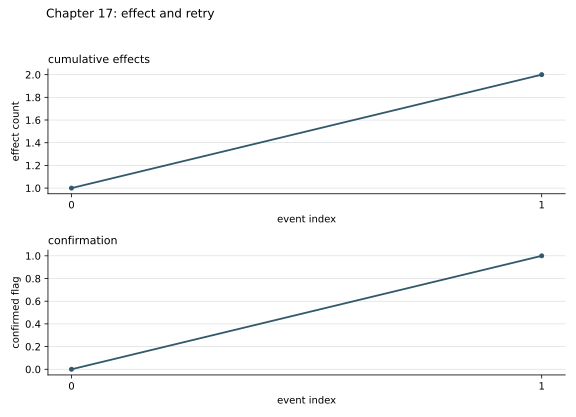

In [3]:
display(SVG(figure_svg(report)))

**Figure 17.L1:** Calculated chapter experiment. Each panel labels its input and output units; interpret it under the assumptions printed in the report.

## Change the assumption

The most dangerous shortcut is to equate an absent acknowledgement with an absent effect. That rule encourages the controller to replay actions whose consequences may already be durable. The converse shortcut also fails: receiving an acknowledgement does not establish that only one effect occurred. The default trace ends with confirmation and a duplicate.

A second failure concerns idempotency scope. A key that is checked only in client memory cannot protect against service restarts, multiple clients, or an independently repeated operation. This implementation assumes the receiver's key ledger is the effect boundary. If a real service has a retention window, payload normalization rule, or transaction boundary, those conditions must be added before adopting the simplified cost comparison.

Verification has its own limitations. The comparison assumes a perfect query, while real observations can be stale or ambiguous. A false negative could provoke another retry; a false positive could terminate a workflow that never completed. Do not treat the returned recommendation as a complete recovery controller. It prices one next step under a declared conditional belief and a specific duplicate-harm contract.

Chapter 17: effect-and-retry
Did the tool act, and should an unresolved request be verified or retried?
Evidence: constructed changed-assumption example

Calculated quantities:
{
  "effects": 1,
  "duplicate_effects": 0,
  "confirmed": true,
  "unresolved": false,
  "verification_cost": 1.0,
  "retry_expected_cost": 0.2,
  "preferred_next_step": "stop"
}

Interpretation:
The ledger distinguishes a real effect from receipt of its acknowledgement. Retry pricing is conditional on the supplied unresolved-effect probability.

Assumptions:
- Trace effect flags describe actual local events.
- Idempotence requires stored key and payload equality.
- Verification is assumed perfect for the cost comparison.

Limitations:
- No remote effect or eventual completion guarantee is inferred.
- The comparison prices one next step, not an entire recovery policy.

Execution: completed locally; constructed inputs are not deployment measurements.


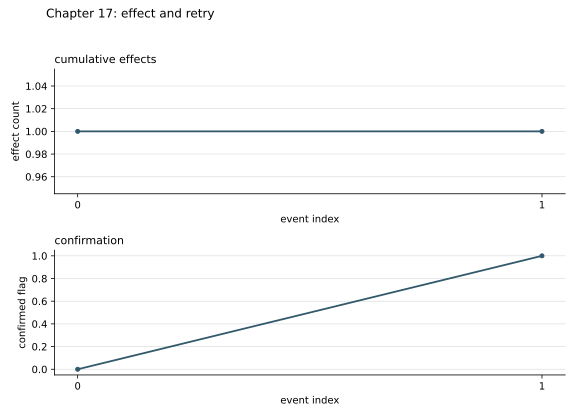

In [4]:
changed_inputs = {'idempotent': True,
 'events': [{'kind': 'request',
             'key': 'release-1',
             'payload': 'edition-A',
             'effect': True,
             'ack': False},
            {'kind': 'request',
             'key': 'release-1',
             'payload': 'edition-A',
             'effect': True,
             'ack': True}],
 'verify_cost': 1,
 'retry_cost': 0.2,
 'effect_probability': 0.8,
 'duplicate_cost': 10}
changed = analyze(chapter, changed_inputs)
changed['evidence_kind'] = 'constructed changed-assumption example'
print(report_text(changed))
display(SVG(figure_svg(changed)))

**Figure 17.L2:** The changed-assumption result. Compare the printed quantities and the stated assumptions with the first run. A different input need not imply a causal effect in a deployed agent.

## Try a new case

The transfer trace uses a request with a lost acknowledgement followed by an explicit verification. Its effect count stays at one, and confirmation becomes true at the second event. The verification cost is 0.5; blind retry would cost 0.1+0.6(4)=2.5, so at an unresolved decision point the declared comparison again favors verification. Because this trace is already confirmed, the reported preferred_next_step is stop.

For reader data, preserve event order and give each effect-bearing request its durable operation identifier. If you have only client logs, mark actual effect as unknown in your measurement design instead of inventing a boolean and passing it to this deterministic replay. Obtain server evidence or construct separate possible traces. Compare those traces to identify which next observation would distinguish them. The method is useful precisely because it refuses to turn transport uncertainty into a fabricated state fact.

In [5]:
transfer_inputs = {'idempotent': False,
 'events': [{'kind': 'request',
             'key': 'send-2',
             'payload': 'packet-B',
             'effect': True,
             'ack': False},
            {'kind': 'verify', 'observed_effect': True}],
 'verify_cost': 0.5,
 'retry_cost': 0.1,
 'effect_probability': 0.6,
 'duplicate_cost': 4}
transfer = analyze(chapter, transfer_inputs)
transfer['evidence_kind'] = 'constructed transfer example'
print(report_text(transfer))

Chapter 17: effect-and-retry
Did the tool act, and should an unresolved request be verified or retried?
Evidence: constructed transfer example

Calculated quantities:
{
  "effects": 1,
  "duplicate_effects": 0,
  "confirmed": true,
  "unresolved": false,
  "verification_cost": 0.5,
  "retry_expected_cost": 2.5,
  "preferred_next_step": "stop"
}

Interpretation:
The ledger distinguishes a real effect from receipt of its acknowledgement. Retry pricing is conditional on the supplied unresolved-effect probability.

Assumptions:
- Trace effect flags describe actual local events.
- Idempotence requires stored key and payload equality.
- Verification is assumed perfect for the cost comparison.

Limitations:
- No remote effect or eventual completion guarantee is inferred.
- The comparison prices one next step, not an entire recovery policy.

Execution: completed locally; constructed inputs are not deployment measurements.


## Apply the method to your inputs

The example file below has the exact input shape the method accepts. Copy it to a new file, replace its values, then point `reader_file` at your copy. Run the cell again. Supplied inputs retain their stated provenance; the program cannot establish that they are representative observations.

- **idempotent:** Exact boolean. True declares server-side key/payload deduplication.
- **events:** Ordered event list: request has kind,key,payload,effect:boolean,ack:boolean; verify has observed_effect:boolean. All requests must concern one logical payload; distinct operations require separate traces.
- **verify_cost:** Nonnegative one-step cost of perfect verification.
- **retry_cost:** Nonnegative one-step request cost.
- **effect_probability:** Probability [0,1] that the unresolved original request already took effect.
- **duplicate_cost:** Nonnegative extra harm from a duplicate effect.

In [6]:
reader_file = LAB_ROOT / 'data/examples/ch17.json'
reader_inputs = json.loads(reader_file.read_text())
reader_report = analyze(chapter, reader_inputs)
print(report_text(reader_report))

Chapter 17: effect-and-retry
Did the tool act, and should an unresolved request be verified or retried?
Evidence: supplied local inputs; provenance not independently verified

Calculated quantities:
{
  "effects": 1,
  "duplicate_effects": 0,
  "confirmed": true,
  "unresolved": false,
  "verification_cost": 0.5,
  "retry_expected_cost": 2.5,
  "preferred_next_step": "stop"
}

Interpretation:
The ledger distinguishes a real effect from receipt of its acknowledgement. Retry pricing is conditional on the supplied unresolved-effect probability.

Assumptions:
- Trace effect flags describe actual local events.
- Idempotence requires stored key and payload equality.
- Verification is assumed perfect for the cost comparison.

Limitations:
- No remote effect or eventual completion guarantee is inferred.
- The comparison prices one next step, not an entire recovery policy.

Execution: completed locally; constructed inputs are not deployment measurements.


## Explore the four chapter demonstrations

The following sections reproduce every demonstration in the illustrated chapter reader. They use the same declared controls, calculation and figure. Begin with the prediction, run the worked case, change one control, then inspect the complete state table. The chapter experiment above remains available for your own compatible inputs.

In [7]:
from math_ai_agents.demos import demo_catalog, demo_states, run_demo, demo_report_text

<a id="demo-c17-d01"></a>

### Demonstration 1: Send it twice: what is different afterward?

For which kinds of request does a repeat leave the intended effect unchanged, and what happens when a key is lost?

![Equation 17.1](../assets/math/521f3b91c8104d451a8b.svg)

**Symbols and units:** T is the tool, x the state of the world, eff(T, x) the state after the tool runs, and eff with subscript I keeps only the coordinates the request asked about (here the record's value). The equation says running T twice gives the same intended coordinates as running it once. Log lines are outside that projection. A safe request is read-only by its defined semantics; a key is a token the service uses to recognize a repeated request.

A read requests no change, and setting a value or deleting a record land in the same place however often they repeat, so the equation holds for all three. A charge adds again each time, so it fails. A stored key lets the service count the charge once, which restores the equation for that request, but only while the service still recognizes the key: a lost key or one past its retention window lets the repeat be applied again. The service may keep a log line per request.

**Use in this chapter:** Ask of every tool: if this is called twice with identical arguments, what is different afterward? Write the answer on the tool definition, because the agent cannot infer it from a name.

**Assumptions:** One tool at one state, with one record and constructed values (start 100, target 150, charge 50). The equation says nothing about sequences of tools, and a key only helps if the service really deduplicates under its contract: it must say what the key identifies, whether the arguments must match, who owns it and how long it is kept. Deduplication is not queryability. The service is also constructed to log every request and to reply as shown.

**Predict before running:** Pick the charge with no key. After three identical requests, will the record end at 150, 200 or 250?

**Controls you can change:**

- **Kind of request (three identical requests are sent):** `kind` accepts 'read', 'put', 'delete', 'charge'.
- **Key for the charge (no effect on the other kinds):** `key` accepts 'none', 'stored', 'lost'.

**Source section:** The classification the specification actually uses.

**Evidence:** constructed teaching example.

Constructed example: values defined for this reader; effects are counted with the laboratory's effect ledger, whose default trace sends two identical requests with no key and whose changed trace stores the key.

Prediction choices:

1. 150
2. 200
3. 250

**Boundary of the conclusion:** RFC 9110 governs HTTP semantics and is not a specification for agent tools; every transfer in this chapter is an argument by analogy that the chapter states rather than assumes. Equation (17.1) covers one tool at one state and not sequences. The retry costs and the belief numbers are constructed for teaching. Chapter 22 takes up what a safety constraint on a measured cost can and cannot guarantee, including why it says little about state the cost does not register.

**Common wrong turn:** The chapter says Equation (17.1) is about effects and not responses: a second DELETE can return a different status code and still leave the same intended absence. Choose Delete: the replies differ, and the equation still holds.

Send it twice: what is different afterward?
Controls: {"kind": "put", "key": "none"}
Evidence: constructed teaching example

Calculated quantities:
Class (Figure 17.2): idempotent
Record after one request: 150
Record after 3 requests: 150
Equation (17.1): holds
Log lines written: 3
Replies: same answer each time
Automatic retry after a lost reply: allowed: the intended effect is unchanged, subject to current authority and the service contract

Worked steps:
1. Start with record value 100. Compare the intended record effect; the service log is a separate coordinate.
2. The first set replaces 100 with the specified value 150.
3. Each later set names that same value 150, so the final record remains 150.
4. Repeated minus single-request effect = 150 - 150 = 0. Equation (17.1) holds in this trace.
5. The log still has 3 lines, one per request. That count is outside the intended effect compared by Equation (17.1).
6. Retry classification: allowed: the intended effect is unchanged, subject to

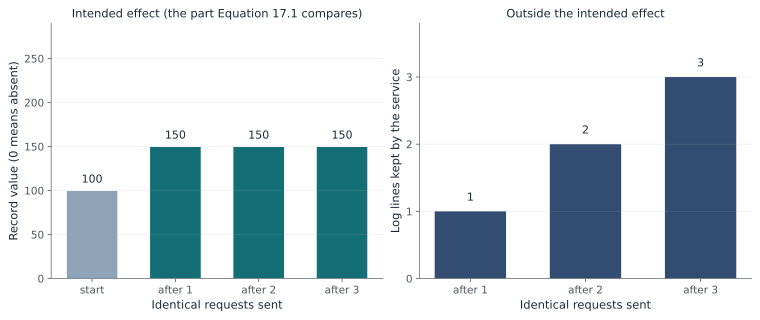

In [8]:
demo_id = 'C17-D01'
demo_controls = {'kind': 'put', 'key': 'none'}
demo_result = run_demo(17, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **Kind of request (three identical requests are sent)** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

Send it twice: what is different afterward?
Controls: {"kind": "read", "key": "none"}
Evidence: constructed teaching example

Calculated quantities:
Class (Figure 17.2): safe (so also idempotent)
Record after one request: 100
Record after 3 requests: 100
Equation (17.1): holds
Log lines written: 3
Replies: the same record each time
Automatic retry after a lost reply: allowed: the intended effect is unchanged, subject to current authority and the service contract

Worked steps:
1. Start with record value 100. Compare the intended record effect; the service log is a separate coordinate.
2. A read changes no intended record value: after one request it is still 100.
3. Each of the 3 reads requests the same no change, so the final record remains 100.
4. Repeated minus single-request effect = 100 - 100 = 0. Equation (17.1) holds in this trace.
5. The log still has 3 lines, one per request. That count is outside the intended effect compared by Equation (17.1).
6. Retry classification: allowed

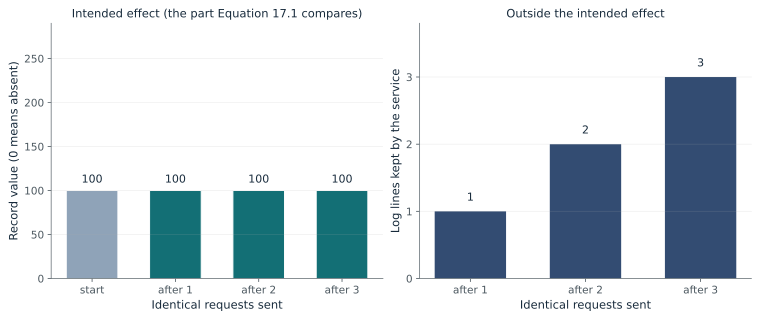

In [9]:
changed_controls = {'kind': 'read', 'key': 'none'}
changed_demo = run_demo(17, 'C17-D01', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [10]:
state_rows = []
for controls in demo_states(17, 'C17-D01'):
    state = run_demo(17, 'C17-D01', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "kind": "read",
      "key": "none"
    },
    "metrics": [
      [
        "Class (Figure 17.2)",
        "safe (so also idempotent)"
      ],
      [
        "Record after one request",
        "100"
      ],
      [
        "Record after 3 requests",
        "100"
      ],
      [
        "Equation (17.1)",
        "holds"
      ],
      [
        "Log lines written",
        "3"
      ],
      [
        "Replies",
        "the same record each time"
      ],
      [
        "Automatic retry after a lost reply",
        "allowed: the intended effect is unchanged, subject to current authority and the service contract"
      ]
    ]
  },
  {
    "controls": {
      "kind": "read",
      "key": "stored"
    },
    "metrics": [
      [
        "Class (Figure 17.2)",
        "safe (so also idempotent)"
      ],
      [
        "Record after one request",
        "100"
      ],
      [
        "Record after 3 requests",
        "100"
      ],
      [
        

**Check your understanding:** A charge of 50 with a stored key is sent 4 times from a record of 100. Where does the record end?

[Answer and worked reasoning](../solutions/ch17.md#demonstration-1). [Matching browser demonstration](../readers/17-effect-and-retry/reader.html#C17-D01).

<a id="demo-c17-d02"></a>

### Demonstration 2: From silence to a decision: retry, decline or read

After no reply, how likely is it that the effect landed, and what does that belief make of a retry, a decline and a perfect read?

![Equation 17.2](../assets/math/9fd25b8ba498db8f883f.svg)

![Equation 17.3](../assets/math/06754fe168697c58639b.svg)

**Symbols and units:** Pr(applied) is the belief that the effect landed, before the silence is taken into account. Obs(silence | applied) is the probability of getting no reply when it did land, and Obs(silence | not applied) the probability of no reply when it did not (0.5 here). b'(applied) is the belief after the silence, written beta in the second equation. In the first equation the empty-set symbol stands for silence, the empty response. The cost written c with subscript miss is the cost of the action never happening (10) and c with subscript dup the cost of applying it twice. EU(retry) minus EU(decline) is how much better a retry is than leaving things alone. A perfect read reveals whether the effect landed, costs 1, creates no effect and finishes while the authorization is valid; after it the agent retries only if the effect is absent.

Bayes' rule weighs how likely silence is in each world by how likely each world was. If the likelihoods are equal they cancel and nothing changes; if silence is more likely when the effect landed, the belief rises. Equation (17.3) then prices a retry against a decline: a retry is right with chance 1 minus the belief and wrong with the belief's own chance, and the difference crosses zero at the missing cost divided by the missing cost plus the duplicate cost. A read that settles which world holds removes both losses, so it pays when the best action without it is dearer than the read. When a duplicate costs nothing, retrying is already as good as acting with the information and the read is worth nothing.

**Use in this chapter:** Do not turn a timeout into a probability by instinct, and do not leave the duplicate cost unpriced: a team that has never written it down has still decided, by leaving the choice to the retry library's default. Ask what the service does when the request lands and what it does when it does not, and what a status read would cost.

**Assumptions:** Two worlds only (applied, not applied), constructed likelihoods with silence 0.5 likely if the request did not apply, and the chapter's teaching construction: authorized attempts, preconditions hold, a retry certainly applies the effect, no other request costs, and the original attempt can no longer apply. The read is perfect and costs 1, as in workbench IV.3. A real transport symptom rarely supplies either likelihood, and an agent that writes its own status report is feeding its own belief. A request fee, expired authority or changed version would change the comparison. The laboratory's own retry price adds the request cost to belief times duplicate cost and compares that with a verification cost; this demonstration sets the request cost to 0 and follows Equation (17.3), so the notebook default (belief 0.8, retry cost 0.2, duplicate cost 10) is a different frame from the states shown.

**Predict before running:** With belief 0.30, a duplicate cost of 40 and a missing cost of 10, which action has the lowest expected cost when a perfect read costs 1?

**Controls you can change:**

- **Belief before silence:** `prior` accepts 0.3, 0.99.
- **Chance of silence if the effect landed:** `silence_if_applied` accepts 0.5, 0.9.
- **Cost of a duplicate effect:** `c_dup` accepts 0, 10, 40.

**Source section:** Stage three: the retry decision, priced.

**Evidence:** constructed teaching example.

Constructed example: the chapter's equal-likelihood baseline and its 0.99 prior; workbench problems IV.1 (belief 0.30, duplicate cost 40, missing cost 10) and IV.3 (a perfect read for 1, and the repeatable interface with duplicate cost 0); the other likelihoods and the duplicate cost 10 are defined for this reader. The duplicate term comes from the laboratory's retry pricing.

Prediction choices:

1. Retry
2. Decline
3. Read first

**Common wrong turn:** The chapter warns that a 99 percent success rate among requests that reach a server does not by itself supply either likelihood of silence. Choose the prior 0.99 with equal silence likelihoods: the belief stays at 0.99, and it moves only when the two likelihoods differ, which the rate does not say.

From silence to a decision: retry, decline or read
Controls: {"prior": 0.3, "silence_if_applied": 0.5, "c_dup": 40}
Evidence: constructed teaching example

Calculated quantities:
Belief before silence (prior): 0.300
Belief after silence (beta): 0.300
Expected cost of retrying: 12.00
Expected cost of declining: 7.00
Cost of reading first: 1.00
EU(retry) minus EU(decline): -5.00
Retry threshold: 0.20
Lowest expected cost: Read first
Gross value of a perfect read: 7.00
Net value of the read: 6.00

Worked steps:
1. Weight if the effect landed: 0.5 x 0.30 = 0.150.
2. Weight if it did not: 0.5 x 0.70 = 0.350.
3. Belief after silence (beta): 0.150 / (0.150 + 0.350) = 0.300.
4. Retry: beta x c_dup = 0.3000 x 40 = 12.00.
5. Decline: (1 - beta) x c_miss = 0.7000 x 10 = 7.00.
6. Equation (17.3): 7.00 - 12.00 = -5.00; threshold 0.20.
7. Perfect read: gross value 7.00, net 7.00 - 1 = 6.00.

Belief after = (0.5 x 0.30) / (0.5 x 0.30 + 0.5 x 0.70) = 0.150 / 0.500 = 0.300. The two likelihoods are equa

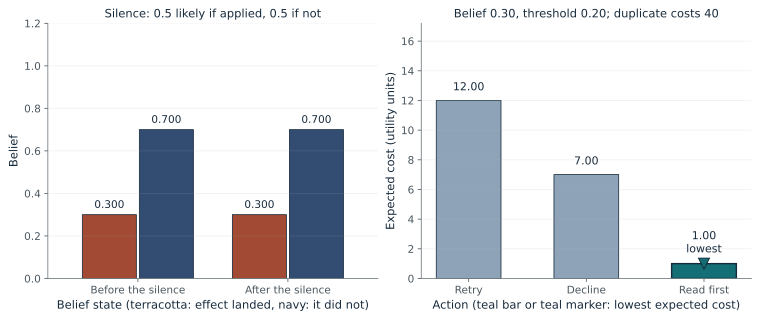

In [11]:
demo_id = 'C17-D02'
demo_controls = {'prior': 0.3, 'silence_if_applied': 0.5, 'c_dup': 40}
demo_result = run_demo(17, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **Belief before silence** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

From silence to a decision: retry, decline or read
Controls: {"prior": 0.99, "silence_if_applied": 0.5, "c_dup": 40}
Evidence: constructed teaching example

Calculated quantities:
Belief before silence (prior): 0.990
Belief after silence (beta): 0.990
Expected cost of retrying: 39.60
Expected cost of declining: 0.10
Cost of reading first: 1.00
EU(retry) minus EU(decline): -39.50
Retry threshold: 0.20
Lowest expected cost: Decline
Gross value of a perfect read: 0.10
Net value of the read: -0.90

Worked steps:
1. Weight if the effect landed: 0.5 x 0.99 = 0.495.
2. Weight if it did not: 0.5 x 0.01 = 0.005.
3. Belief after silence (beta): 0.495 / (0.495 + 0.005) = 0.990.
4. Retry: beta x c_dup = 0.9900 x 40 = 39.60.
5. Decline: (1 - beta) x c_miss = 0.0100 x 10 = 0.10.
6. Equation (17.3): 0.10 - 39.60 = -39.50; threshold 0.20.
7. Perfect read: gross value 0.10, net 0.10 - 1 = -0.90.

Belief after = (0.5 x 0.99) / (0.5 x 0.99 + 0.5 x 0.01) = 0.495 / 0.500 = 0.990. The two likelihoods are eq

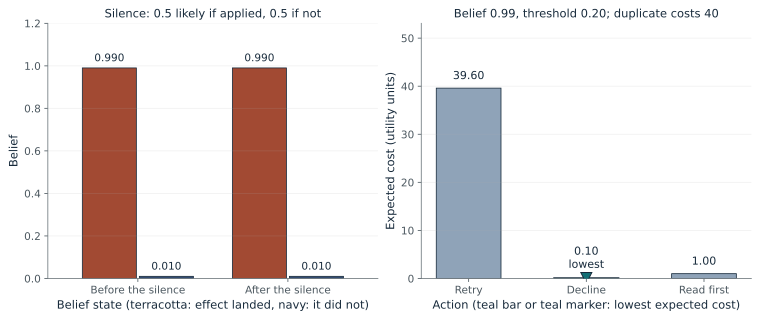

In [12]:
changed_controls = {'prior': 0.99, 'silence_if_applied': 0.5, 'c_dup': 40}
changed_demo = run_demo(17, 'C17-D02', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [13]:
state_rows = []
for controls in demo_states(17, 'C17-D02'):
    state = run_demo(17, 'C17-D02', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "prior": 0.3,
      "silence_if_applied": 0.5,
      "c_dup": 0
    },
    "metrics": [
      [
        "Belief before silence (prior)",
        "0.300"
      ],
      [
        "Belief after silence (beta)",
        "0.300"
      ],
      [
        "Expected cost of retrying",
        "0.00"
      ],
      [
        "Expected cost of declining",
        "7.00"
      ],
      [
        "Cost of reading first",
        "1.00"
      ],
      [
        "EU(retry) minus EU(decline)",
        "7.00"
      ],
      [
        "Retry threshold",
        "1.00"
      ],
      [
        "Lowest expected cost",
        "Retry"
      ],
      [
        "Gross value of a perfect read",
        "0.00"
      ],
      [
        "Net value of the read",
        "-1.00"
      ]
    ]
  },
  {
    "controls": {
      "prior": 0.3,
      "silence_if_applied": 0.5,
      "c_dup": 10
    },
    "metrics": [
      [
        "Belief before silence (prior)",
        "0.300"
      

**Check your understanding:** Prior belief 0.2 with silence 0.9 likely if applied and 0.5 if not, a missing cost of 10 and a duplicate cost of 10. What is the belief after silence, and does a retry beat a decline?

[Answer and worked reasoning](../solutions/ch17.md#demonstration-2). [Matching browser demonstration](../readers/17-effect-and-retry/reader.html#C17-D02).

<a id="demo-c17-d03"></a>

### Demonstration 3: Recovery before a repeat: how an undo can fail

When does a recovery tool count as Restored, and how can it fail to?

![Equation 17.4](../assets/math/574a1266b01fa51afc80.svg)

**Symbols and units:** Restored(T, x) is one of the three routes inside the braces of the equation: recovery has already succeeded and verified restoration of every relevant precondition and consequence required for another attempt. Here the relevant consequences are the four in the figure, taken from the chapter's refund example. The stages follow the chapter: observe what happened, perform an authorized repair, then verify and check the fresh attempt's preconditions.

Restored is a conclusion about a finished sequence, not about a tool. Reading the ledger shows what happened; the undo is another call with its own ways to fail: it may be absent or expired, so it cannot run; it may be partial, restoring some consequences and not others; or it may itself be lost, which repeats the retry question one level down. Only the last stage, verification of every relevant consequence, can make Restored true, and the repeat is then eligible only if Ready also holds.

**Use in this chapter:** Treat membership by the recovery route as a claim that needs evidence, like the observation route. Give the recovery path its own retry and escalation limits, so that an agent cannot spend its whole budget trying to clean up.

**Assumptions:** The four consequences and their statuses are constructed from the chapter's refund example; a real recovery has its own list. Absent and expired are shown together because both mean no undo can run; the chapter distinguishes them (none exists, or its window closed). Verification is taken to be a reliable read; in the lost-undo outcome no verifying read has been made yet, so nothing counts as verified, and once the read is made that outcome becomes one of the other three. Outstanding attempts must also be resolved or fenced against delayed effects, which this figure does not draw.

**Predict before running:** Choose the partial undo and move to stage 3. Is Restored true once the money is back?

**Controls you can change:**

- **Stage of the recovery sequence:** `stage` accepts 1, 2, 3.
- **How the undo goes:** `outcome` accepts 'works', 'unavailable', 'partial', 'lost'.

**Source section:** The four ways an undo fails.

**Evidence:** constructed teaching example.

Constructed example: the chapter's refund, confirmation email, downstream webhook and partner ledger entry, and its four ways an undo fails; the notebook's transfer trace (a request with a lost reply, then a read) supplies the ledger entry in stage 1 through the laboratory's effect ledger.

Prediction choices:

1. Yes: the main consequence is undone
2. No: only 1 of 4 consequences is verified restored
3. It cannot be decided

**Common wrong turn:** The chapter says an undo is not a mathematical inverse: a refund is not the absence of a charge but a second transaction that leaves two ledger entries, takes days and can itself fail. Merely having an undo tool does not establish Restored, which denotes completed, verified recovery.

Recovery before a repeat: how an undo can fail
Controls: {"stage": 1, "outcome": "works"}
Evidence: constructed teaching example

Calculated quantities:
Stage: 1. Observe: read what happened
Undo outcome: undo works
Charge entries on the ledger (at the stage 1 read): 1
Coordinates verified restored: 0 of 4
Restored(T, x): false
Route 3 of Equation (17.4): does not hold

Worked steps:
1. The original request landed but its reply was lost.
2. A read of the ledger shows 1 charge entry and confirms it: applied and complete.
3. Coordinates verified restored: 0 + 0 + 0 + 0 = 0 of 4.
4. Do not repeat the charge; start recovery only if the charge is not wanted.

Verified restored = 0 + 0 + 0 + 0 = 0 of 4, and Restored needs 4 of 4, so Restored(T, x) is false. A read of the ledger finds 1 charge entry and confirms it, so the original request is applied and complete; none of its consequences is undone yet. Do not send another charge: the read shows it landed. Any repeat needs a recovery that is 

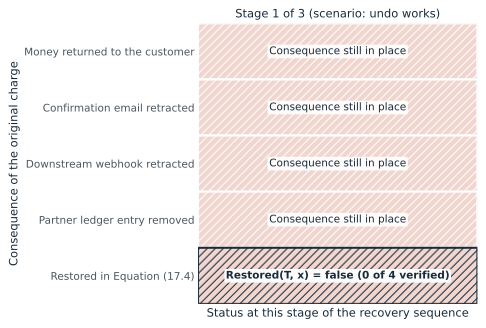

In [14]:
demo_id = 'C17-D03'
demo_controls = {'stage': 1, 'outcome': 'works'}
demo_result = run_demo(17, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **Stage of the recovery sequence** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

Recovery before a repeat: how an undo can fail
Controls: {"stage": 2, "outcome": "works"}
Evidence: constructed teaching example

Calculated quantities:
Stage: 2. Run the undo
Undo outcome: undo works
Charge entries on the ledger (at the stage 1 read): 1
Coordinates verified restored: 0 of 4
Restored(T, x): false
Route 3 of Equation (17.4): does not hold

Worked steps:
1. Run the undo (a second transaction, not the absence of the charge).
2. Result: undo works.
3. Coordinates verified restored so far: 0 + 0 + 0 + 0 = 0 of 4, because nothing is verified yet.
4. Verify before treating anything as restored.

Verified restored = 0 + 0 + 0 + 0 = 0 of 4, and Restored needs 4 of 4, so Restored(T, x) is false. The undo ran and reports success on every consequence, but a report is not verification. Verify the result of the undo before treating anything as restored.

Assumptions: The four consequences and their statuses are constructed from the chapter's refund example; a real recovery has its o

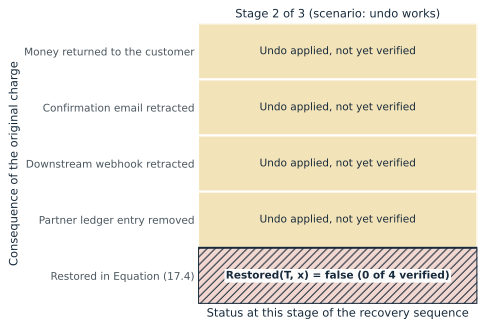

In [15]:
changed_controls = {'stage': 2, 'outcome': 'works'}
changed_demo = run_demo(17, 'C17-D03', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [16]:
state_rows = []
for controls in demo_states(17, 'C17-D03'):
    state = run_demo(17, 'C17-D03', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "stage": 1,
      "outcome": "works"
    },
    "metrics": [
      [
        "Stage",
        "1. Observe: read what happened"
      ],
      [
        "Undo outcome",
        "undo works"
      ],
      [
        "Charge entries on the ledger (at the stage 1 read)",
        "1"
      ],
      [
        "Coordinates verified restored",
        "0 of 4"
      ],
      [
        "Restored(T, x)",
        "false"
      ],
      [
        "Route 3 of Equation (17.4)",
        "does not hold"
      ]
    ]
  },
  {
    "controls": {
      "stage": 1,
      "outcome": "unavailable"
    },
    "metrics": [
      [
        "Stage",
        "1. Observe: read what happened"
      ],
      [
        "Undo outcome",
        "no undo can run"
      ],
      [
        "Charge entries on the ledger (at the stage 1 read)",
        "1"
      ],
      [
        "Coordinates verified restored",
        "0 of 4"
      ],
      [
        "Restored(T, x)",
        "false"
     

**Check your understanding:** A refund returns the money and retracts the email, but the downstream webhook and the partner's ledger entry stay. How many of the four consequences are verified restored, and is Restored true?

[Answer and worked reasoning](../solutions/ch17.md#demonstration-3). [Matching browser demonstration](../readers/17-effect-and-retry/reader.html#C17-D03).

<a id="demo-c17-d04"></a>

### Demonstration 4: Which repeats are eligible: the six-step plan

For each step of the duplicate-record plan, does a lost reply leave a repeat eligible?

![Equation 17.4](../assets/math/574a1266b01fa51afc80.svg)

**Symbols and units:** Rep(x) is the set of tools T whose repeat attempt is eligible at state x. Ready(T, x) means authority, preconditions and retry limits hold now. Absent(T, x) means authoritative proof the original never applied and cannot apply later. Restored(T, x) means recovery succeeded and was verified; none has run here. The plan is the chapter's: search, read both, write a merged record, delete the older one, notify the customer, log to an audit system.

Equation (17.4) is a logical gate: the request must be Ready and at least one route must hold, either idempotent semantics for this request, proof of terminal non-application, or verified restoration. Steps 3 and 4 have plausible idempotent semantics, so they pass when authority is current; steps 5 and 6 do not, so they need a read that proves the original never applied. An expired authority removes every step whatever the evidence.

**Use in this chapter:** Before a retry leaves, run the gate on that request, not on the plan. If it fails, the next step may be a read, a recovery, a deliberate risk decision or a person. A posterior near zero is a risk estimate, not proof of absence.

**Assumptions:** The set is the chapter's conservative construction, not a rule from the HTTP standard. Steps 3 and 4 are idempotent only with stable identifiers and appropriate concurrency conditions; a record version may change between reading and writing. Steps 1 and 2 (search and read) have read-only semantics and are left out. If a read shows a request applied and complete, nothing here is repeated. Evidence goes stale: authority can expire and a version check can become out of date.

**Predict before running:** With authority current and no extra evidence, is a repeat of the customer notification (step 5) eligible?

**Controls you can change:**

- **Step whose reply was lost:** `step` accepts 'merge', 'delete', 'notify', 'audit'.
- **Evidence in hand:** `evidence` accepts 'none', 'absent', 'expired'.

**Source section:** A trajectory, classified.

**Evidence:** constructed teaching example.

Constructed example: the chapter's six-step plan and its classification of each step; the evidence cases are defined for this reader from the chapter's own routes.

Prediction choices:

1. Yes, it is eligible
2. No, it is not eligible

**Common wrong turn:** The chapter says a sequence of idempotent operations is not idempotent in general, because reapplying a sequence from the middle can interleave with what the first pass already did, and that there is no general rule that sorting operations by membership in Rep(x) produces a valid plan. Equation (17.1) is about one tool at one state.

Which repeats are eligible: the six-step plan
Controls: {"step": "merge", "evidence": "none"}
Evidence: constructed teaching example

Calculated quantities:
Step: Step 3: write the merged record
Ready: true
Routes that hold: 1 of 3
Membership: in Rep(x)

Worked steps:
1. Step 3: write the merged record: idempotent for this request? yes, so route 1 is 1.
2. Evidence: no extra evidence; route 2 (Absent) is 0, route 3 (Restored) is 0.
3. Routes held = 1 + 0 + 0 = 1.
4. Ready = 1; Ready x routes held = 1 x 1 = 1.
5. In Rep(x).

Writing a specified merged record can be idempotent with respect to that content, if identifiers are stable and the write carries a version condition. Routes held = 1 + 0 + 0 = 1. Ready x routes held = 1 x 1 = 1, and any positive result is membership. The request is in Rep(x): a repeat is eligible, though eligible does not mean free, harmless or required.

Assumptions: The set is the chapter's conservative construction, not a rule from the HTTP standard. Steps 3 and

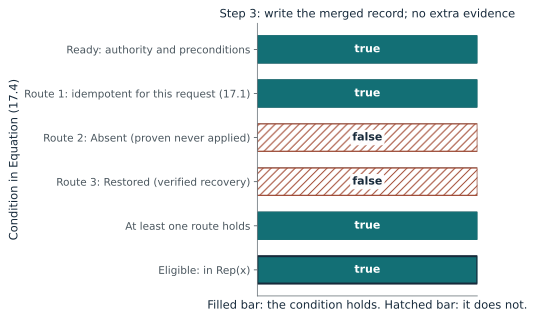

In [17]:
demo_id = 'C17-D04'
demo_controls = {'step': 'merge', 'evidence': 'none'}
demo_result = run_demo(17, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **Step whose reply was lost** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

Which repeats are eligible: the six-step plan
Controls: {"step": "delete", "evidence": "none"}
Evidence: constructed teaching example

Calculated quantities:
Step: Step 4: delete the older record
Ready: true
Routes that hold: 1 of 3
Membership: in Rep(x)

Worked steps:
1. Step 4: delete the older record: idempotent for this request? yes, so route 1 is 1.
2. Evidence: no extra evidence; route 2 (Absent) is 0, route 3 (Restored) is 0.
3. Routes held = 1 + 0 + 0 = 1.
4. Ready = 1; Ready x routes held = 1 x 1 = 1.
5. In Rep(x).

Deleting a specific older record can be idempotent with respect to its absence, but repeating a delete and undoing it are different questions: the older contents are gone unless they were retained. Routes held = 1 + 0 + 0 = 1. Ready x routes held = 1 x 1 = 1, and any positive result is membership. The request is in Rep(x): a repeat is eligible, though eligible does not mean free, harmless or required.

Assumptions: The set is the chapter's conservative construction

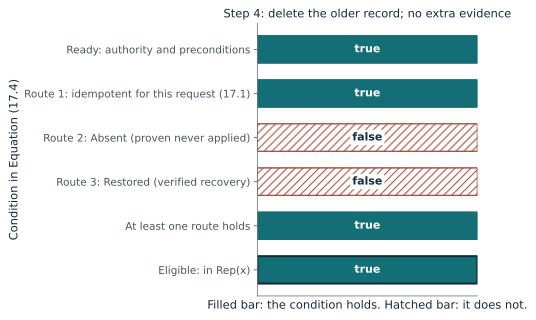

In [18]:
changed_controls = {'step': 'delete', 'evidence': 'none'}
changed_demo = run_demo(17, 'C17-D04', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [19]:
state_rows = []
for controls in demo_states(17, 'C17-D04'):
    state = run_demo(17, 'C17-D04', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "step": "merge",
      "evidence": "none"
    },
    "metrics": [
      [
        "Step",
        "Step 3: write the merged record"
      ],
      [
        "Ready",
        "true"
      ],
      [
        "Routes that hold",
        "1 of 3"
      ],
      [
        "Membership",
        "in Rep(x)"
      ]
    ]
  },
  {
    "controls": {
      "step": "merge",
      "evidence": "absent"
    },
    "metrics": [
      [
        "Step",
        "Step 3: write the merged record"
      ],
      [
        "Ready",
        "true"
      ],
      [
        "Routes that hold",
        "2 of 3"
      ],
      [
        "Membership",
        "in Rep(x)"
      ]
    ]
  },
  {
    "controls": {
      "step": "merge",
      "evidence": "expired"
    },
    "metrics": [
      [
        "Step",
        "Step 3: write the merged record"
      ],
      [
        "Ready",
        "false"
      ],
      [
        "Routes that hold",
        "1 of 3"
      ],
      [
      

**Check your understanding:** A read proves a non-idempotent charge was applied and complete. Is the charge in Rep(x)?

[Answer and worked reasoning](../solutions/ch17.md#demonstration-4). [Matching browser demonstration](../readers/17-effect-and-retry/reader.html#C17-D04).

## Questions

1. How many effects occur in the default trace?

2. What duplicate-harm value makes verification and retry tie?

3. What happens when a stored idempotency key is reused with a different payload?

Answers: [separate solutions](../solutions/ch17.md). Try the calculation before opening them.

## Summary

An action, an effect, and an acknowledgement are different events. The ledger counts effects separately from confirmation and shows how a blind retry can duplicate a completed operation. A valid idempotency contract suppresses repeated same-key, same-payload effects; a key conflict is rejected. The next-step cost comparison uses a declared unresolved-effect probability and duplicate harm. It does not guarantee recovery or infer remote state. For practical use, preserve durable identifiers, verify ambiguous consequences, and record the service-side conditions that make replay safe. A confirmed effect can still be duplicated, unauthorized, or incomplete at the workflow level.

Limits of this experiment:

- This is a local calculation under declared inputs, not an empirical claim about a deployed agent.
- Read the returned assumptions and limitations before applying the numerical result.

The assistant skill is [`maa-17-effect-and-retry`](../skills/maa-17-effect-and-retry/SKILL.md). It uses this notebook's tested computation and input contract.

## Equations from the chapter

These are the unchanged display equations and their explanations from the canonical chapter. They are a reference for the experiment, not a claim that every equation is numerically implemented by this one method.

### Equation 17.1

![Equation 17.1](../assets/math/521f3b91c8104d451a8b.svg)

Equation (17.1) requires repeated application to preserve the same intended effect as one application.

Compare the resulting requested-effect coordinates after one application and after two, keeping the request semantics fixed.

LaTeX source, preserved for inspection:

```latex
\operatorname{eff}_{I}\!\big(\operatorname{eff}(T,\operatorname{eff}(T,x))\big) \;=\; \operatorname{eff}_{I}\!\big(\operatorname{eff}(T,x)\big)
\qquad\text{for every reachable } x .
\tag{17.1}
```

### Equation 17.2

![Equation 17.2](../assets/math/9fd25b8ba498db8f883f.svg)

Equation (17.2) converts a missing response into a probability that the action already happened.

Weigh how likely silence is when the effect landed against how likely silence is when it did not.

LaTeX source, preserved for inspection:

```latex
\mathbf{b}'(\text{applied}) \;=\;
\frac{\operatorname{Obs}(\varnothing \mid \text{applied})\;\Pr(\text{applied})}
{\begin{gathered}
\operatorname{Obs}(\varnothing \mid \text{applied})\,\Pr(\text{applied}) \\
{}+\; \operatorname{Obs}(\varnothing \mid \text{not applied})\,\Pr(\text{not applied})
\end{gathered}}.
\tag{17.2}
```

### Equation 17.3

![Equation 17.3](../assets/math/06754fe168697c58639b.svg)

Equation (17.3) says whether sending the request again is worth it.

Weigh the chance the action is still needed, times the cost of skipping it, against the chance it already happened, times the cost of doing it twice.

LaTeX source, preserved for inspection:

```latex
\operatorname{EU}(\text{retry}) - \operatorname{EU}(\text{decline}) \;=\; (1-\beta)\,c_{\text{miss}} \;-\; \beta\,c_{\text{dup}} .
\tag{17.3}
```

### Equation 17.4

![Equation 17.4](../assets/math/574a1266b01fa51afc80.svg)

Equation (17.4) identifies repeat attempts whose duplicate-effect risk is resolved and whose current execution conditions have been checked.

Check authority and preconditions, then require applicable idempotent semantics, proof of terminal non-application, or verified restoration after completed recovery.

LaTeX source, preserved for inspection:

```latex
\operatorname{Rep}(x) \;=\; \Big\{\, T \;:\; \operatorname{Ready}(T,x)\;\land\;\big[\text{(17.1) holds for this request}\;\lor\;\operatorname{Absent}(T,x)\;\lor\;\operatorname{Restored}(T,x)\big] \,\Big\}.
\tag{17.4}
```